# Stage 3 - Effort correction + stabilization

Stage 2 left us two cleaned, source-tagged occurrence tables. Naively mapping
*A. americanum* counts over time conflates **range expansion** with **observer
effort**: iNaturalist usage exploded over the last decade, so cells light up
wherever people are, not (only) where the tick is. Stage 3 removes that bias.

The method, per `h3_cell` per rolling 3-year window:

$$\text{ratio} = \frac{\#\,\text{iNaturalist }A.\,americanum}{\#\,\text{iNaturalist Ixodidae (all ticks)}}$$

= the **share of iNaturalist tick-spotting effort that was lone star**. Numerator
and denominator come from the *same* opportunistic stream, so platform growth
cancels. The denominator is the **iNaturalist subset** of the Ixodidae
background only - never the full background (which is ~88% NEON). NEON is kept
as a separate structured presence layer and never enters the ratio.

Thin cells (most cells see only 1-2 iNaturalist ticks per window) are stabilized
with an **empirical-Bayes beta-binomial shrinkage** toward the global rate.

All logic lives in `src/stage3.py`; all knobs live in `src/config.py`. This
notebook runs the pipeline and reports the four required diagnostics. We read
**only** from `data/processed/`; `data/raw/` and `data/interim/` are untouched.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import geopandas as gpd

# Make src/ importable (config.py, stage3.py) regardless of cwd.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import config
import stage3

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Stage 3 config knobs in play this run:")
print(f"  WINDOW_LENGTH / STEP          = {config.WINDOW_LENGTH_YEARS}yr / {config.WINDOW_STEP_YEARS}yr")
print(f"  WINDOW_START_YEAR             = {config.WINDOW_START_YEAR}")
print(f"  WINDOW_END_YEAR               = {config.WINDOW_END_YEAR} (None -> derive from data)")
print(f"  NORTHERN_LIMIT_PERCENTILE     = {config.NORTHERN_LIMIT_PERCENTILE}")
print(f"  OCCUPIED_INTENSITY_THRESHOLD  = {config.OCCUPIED_INTENSITY_THRESHOLD}")
print(f"  RAW_MIN_COUNT                 = {config.RAW_MIN_COUNT}")
print(f"  COUNTY_MAX_UNCERTAINTY_M      = {config.COUNTY_MAX_UNCERTAINTY_M:,.0f} m")
print(f"  H3_RESOLUTION                 = {config.H3_RESOLUTION}")

Stage 3 config knobs in play this run:
  WINDOW_LENGTH / STEP          = 3yr / 1yr
  WINDOW_START_YEAR             = 2015
  WINDOW_END_YEAR               = None (None -> derive from data)
  NORTHERN_LIMIT_PERCENTILE     = 0.95
  OCCUPIED_INTENSITY_THRESHOLD  = 0.1
  RAW_MIN_COUNT                 = 1
  COUNTY_MAX_UNCERTAINTY_M      = 50,000 m
  H3_RESOLUTION                 = 5


## 1. Run the Stage 3 pipeline

`stage3.run_stage3()` builds every layer from the processed background table and
writes the four deliverables to `data/processed/`:

- `effort_corrected_cells.parquet` - per cell/window numerator, denominator,
  raw_ratio, shrunk_ratio.
- `neon_presence.parquet` - NEON "lone star detected" boolean per cell/window.
- `frontier_metrics.csv` - raw vs corrected northern limit / centroid / area.
- `county_detections.parquet` - iNat + NEON detections per county/window.

The US county polygons for the county join are fetched once and cached under
`.cache/` (never into `raw/` or `interim/`).

In [2]:
out = stage3.run_stage3(write=True)

windows = out["windows"]
cells = out["effort_cells"]
neon = out["neon_presence"]
frontier = out["frontier"]
county = out["county_detections"]
prior = out["prior"]

latest_window = windows["window"].iloc[-1]
print(f"\nWindows ({len(windows)}):", ", ".join(windows["window"]))
print(f"Most recent window: {latest_window}")
print(f"Effort cell-windows: {len(cells):,} across {cells['h3_cell'].nunique():,} unique cells")
print(f"NEON presence cell-windows: {len(neon):,} (lone-star-positive: {int(neon['lone_star_detected'].sum()):,})")
print(f"County-windows: {len(county):,} across {county['county_fips'].nunique():,} counties")

22:34:38 | INFO    | Loaded processed: background=411641 rows, target=38916 rows


22:34:38 | INFO    | Built 10 rolling windows (length=3yr, step=1yr): 2015-2017, 2016-2018, 2017-2019, 2018-2020, 2019-2021, 2020-2022, 2021-2023, 2022-2024, 2023-2025, 2024-2026


22:34:39 | INFO    | NEON presence: 387 cell-windows | lone-star-positive=153 | NEON-sampled cells (unique)=50


22:34:39 | INFO    | Effort cells: 27903 cell-windows across 6480 unique cells | numerator total=17503, denominator total=86777, pooled rate=0.2017


22:34:40 | INFO    | Beta prior (beta-binomial-mle): alpha=0.1929 beta=0.7590 -> mean=0.2027, strength=0.95 (pooled rate=0.2017, 27903 cell-windows)


...

22:34:41 | INFO    | Loaded county polygons from cache (3221 features)


22:34:41 | INFO    |   53 detections fell outside all county polygons (offshore / border slivers); dropped from county table


22:34:42 | INFO    | County detections: 5120 county-windows across 1103 unique counties


22:34:42 | INFO    | Wrote Stage 3 outputs -> C:\Users\Arv\OneDrive\Desktop\lone-star-tick-spread\data\processed



Windows (10): 2015-2017, 2016-2018, 2017-2019, 2018-2020, 2019-2021, 2020-2022, 2021-2023, 2022-2024, 2023-2025, 2024-2026
Most recent window: 2024-2026
Effort cell-windows: 27,903 across 6,480 unique cells
NEON presence cell-windows: 387 (lone-star-positive: 153)
County-windows: 5,120 across 1,103 counties


## 2. Distribution of denominators per cell-window

This is the justification for shrinkage. If most cells had hundreds of
iNaturalist tick observations, the raw ratio would be stable and we could stop.
Instead the denominator is tiny almost everywhere - so a single lucky lone-star
sighting in a 1-observation cell yields `raw_ratio = 1.0`, a wildly
overconfident frontier signal.

denominator: median=1, mean=3.11, max=762
  cell-windows with denominator == 1 :  53.2%
  cell-windows with denominator <= 2 :  71.1%
  cell-windows with denominator <= 5 :  88.5%


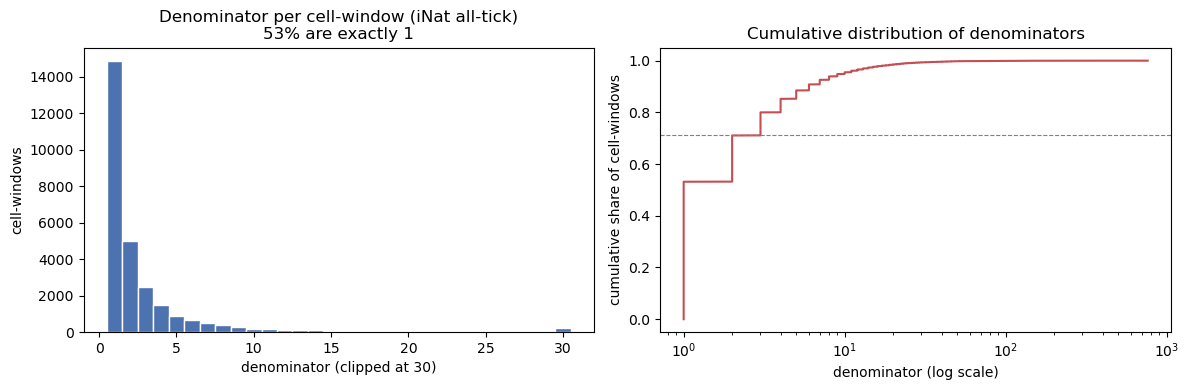

In [3]:
den = cells["denominator"]
share_le2 = (den <= 2).mean()
share_eq1 = (den == 1).mean()
print(f"denominator: median={den.median():.0f}, mean={den.mean():.2f}, max={den.max():.0f}")
print(f"  cell-windows with denominator == 1 : {share_eq1:6.1%}")
print(f"  cell-windows with denominator <= 2 : {share_le2:6.1%}")
print(f"  cell-windows with denominator <= 5 : {(den <= 5).mean():6.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cap = 30
axes[0].hist(den.clip(upper=cap), bins=np.arange(1, cap + 2) - 0.5,
             color="#4C72B0", edgecolor="white")
axes[0].set_title(f"Denominator per cell-window (iNat all-tick)\n{share_eq1:.0%} are exactly 1")
axes[0].set_xlabel(f"denominator (clipped at {cap})")
axes[0].set_ylabel("cell-windows")

sorted_den = np.sort(den.values)
cdf = np.arange(1, len(sorted_den) + 1) / len(sorted_den)
axes[1].plot(sorted_den, cdf, color="#C44E52")
axes[1].set_xscale("log")
axes[1].axhline(share_le2, color="0.5", ls="--", lw=0.8)
axes[1].set_title("Cumulative distribution of denominators")
axes[1].set_xlabel("denominator (log scale)")
axes[1].set_ylabel("cumulative share of cell-windows")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage3_denominator_distribution.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 3. The fitted prior and the shrinkage diagnostic

We fit a global beta$(\alpha, \beta)$ prior to the pooled cell-window counts by
maximum likelihood of the beta-binomial marginal, then report the posterior mean
$\text{shrunk} = (k + \alpha)/(n + \alpha + \beta)$ per cell-window. The prior
mean equals the global pooled lone-star share; the prior *strength*
$(\alpha + \beta)$ is how many pseudo-observations a thin cell is pulled toward
it by.

The diagnostic below plots raw vs shrunk ratio. Cells on the 45-degree line
didn't move (data-rich); cells yanked toward the prior mean are the thin, noisy
ones - exactly the cells that would otherwise fake a frontier.

Fitted beta prior:
  alpha                  = 0.19290621601152125
  beta                   = 0.7589887682006519
  prior_mean             = 0.20265493485206065
  prior_strength         = 0.9518949842121731
  pooled_rate            = 0.2017009115318575
  method                 = beta-binomial-mle
  n_cellwindows          = 27903

Shrinkage movement |shrunk - raw|: mean=0.114, median=0.099, max=0.389


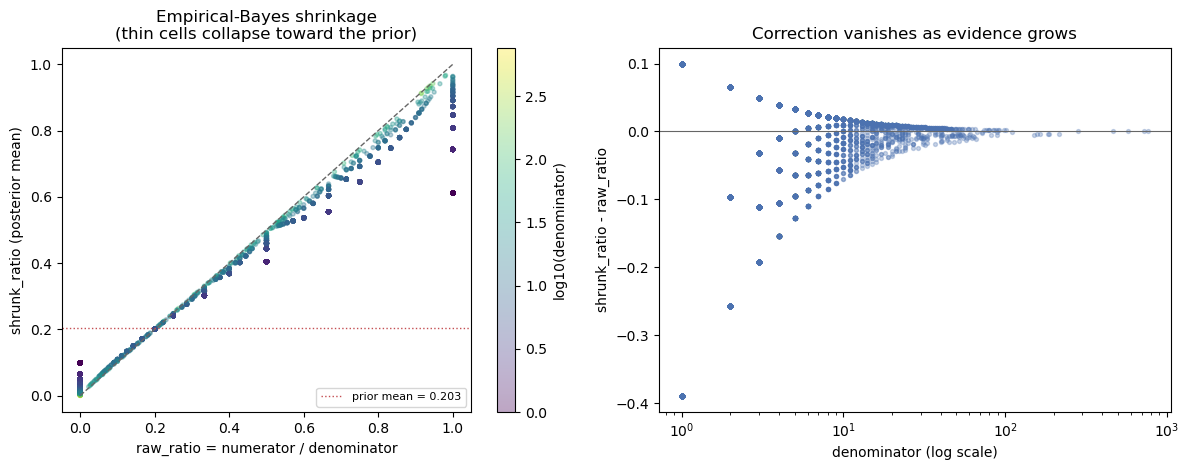

In [4]:
print("Fitted beta prior:")
for k, v in prior.items():
    print(f"  {k:22s} = {v}")

delta = cells["shrinkage_delta"].abs()
print(f"\nShrinkage movement |shrunk - raw|: mean={delta.mean():.3f}, "
      f"median={delta.median():.3f}, max={delta.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sc = axes[0].scatter(cells["raw_ratio"], cells["shrunk_ratio"],
                     c=np.log10(cells["denominator"]), s=8, alpha=0.35,
                     cmap="viridis")
axes[0].plot([0, 1], [0, 1], color="0.4", ls="--", lw=1)
axes[0].axhline(prior["prior_mean"], color="#C44E52", ls=":", lw=1,
                label=f"prior mean = {prior['prior_mean']:.3f}")
axes[0].set_xlabel("raw_ratio = numerator / denominator")
axes[0].set_ylabel("shrunk_ratio (posterior mean)")
axes[0].set_title("Empirical-Bayes shrinkage\n(thin cells collapse toward the prior)")
axes[0].legend(loc="lower right", fontsize=8)
cb = fig.colorbar(sc, ax=axes[0])
cb.set_label("log10(denominator)")

axes[1].scatter(cells["denominator"], cells["shrinkage_delta"], s=8, alpha=0.3,
                color="#4C72B0")
axes[1].axhline(0, color="0.4", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xlabel("denominator (log scale)")
axes[1].set_ylabel("shrunk_ratio - raw_ratio")
axes[1].set_title("Correction vanishes as evidence grows")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage3_shrinkage_diagnostic.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 4. Raw vs corrected surface - most recent window

Side by side for the latest window. Left = **raw** effort ratio; right =
**shrunk** ratio. Point size encodes the denominator (sampling evidence). The
raw panel is littered with full-saturation specks - 1-of-1 cells screaming
`ratio = 1.0` - many of them far north. The corrected panel deflates those
evidence-poor specks toward the prior while leaving the well-sampled, genuinely
lone-star-dominated cells bright. That difference is the observer-effort bias
being removed.

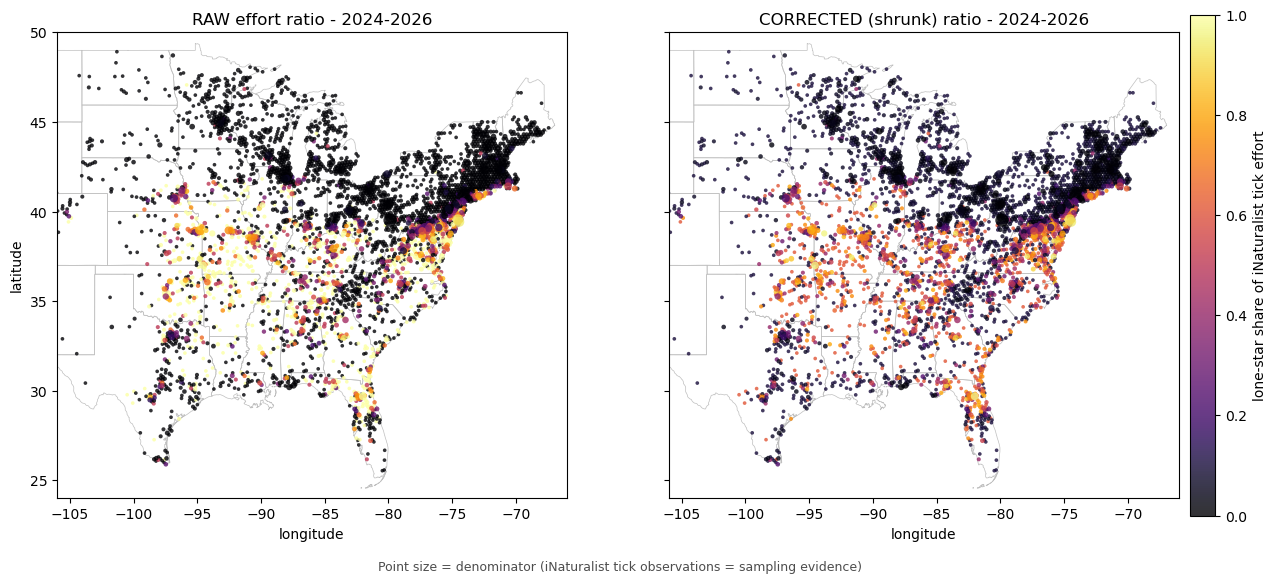

In [5]:
# Light CONUS-east basemap from the cached county polygons (no extra fetch,
# never touches raw/interim). Dissolve counties -> state outlines for context.
states = None
try:
    cty_cache = config.CACHE_DIR / config.COUNTY_GEOJSON_CACHE
    if cty_cache.exists():
        gdf = gpd.read_file(cty_cache)
        if "id" in gdf.columns:
            gdf["state2"] = gdf["id"].astype(str).str.zfill(5).str[:2]
        else:
            gdf["state2"] = gdf["GEO_ID"].astype(str).str[-5:-3]
        states = gdf.dissolve(by="state2")
except Exception as exc:
    print("basemap unavailable, plotting points only:", exc)

cur = cells[cells["window"] == latest_window].copy()
thr = config.OCCUPIED_INTENSITY_THRESHOLD

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharex=True, sharey=True)
for ax, col, title in (
    (axes[0], "raw_ratio", f"RAW effort ratio - {latest_window}"),
    (axes[1], "shrunk_ratio", f"CORRECTED (shrunk) ratio - {latest_window}"),
):
    if states is not None:
        states.boundary.plot(ax=ax, color="0.75", linewidth=0.5, zorder=1)
    order = cur.sort_values("denominator")
    sc = ax.scatter(order["cell_lon"], order["cell_lat"], c=order[col],
                    s=3 + 4 * np.sqrt(order["denominator"]), cmap="inferno",
                    vmin=0, vmax=1, alpha=0.8, edgecolor="none", zorder=2)
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_xlim(-106, -66)
    ax.set_ylim(24, 50)
axes[0].set_ylabel("latitude")
cb = fig.colorbar(sc, ax=axes, fraction=0.025, pad=0.01)
cb.set_label("lone-star share of iNaturalist tick effort")
fig.suptitle(
    "Point size = denominator (iNaturalist tick observations = sampling evidence)",
    y=0.04, fontsize=9, color="0.3")
fig.savefig(config.FIGURES_DIR / "stage3_raw_vs_corrected_map.png", dpi=150,
            bbox_inches="tight")
plt.show()

## 5. Frontier trajectory across windows - raw vs corrected

The headline contrast. For each window we compute, on **both** surfaces:

- **northern range limit** = the 95th-percentile latitude of positive cells
  (robust to a single northern outlier), and
- **intensity-weighted centroid latitude** (raw = weighted by *A. americanum*
  counts; corrected = weighted by the shrunk effort ratio).

If apparent northward motion were just more iNaturalist users showing up in
already-occupied northern metros, the corrected trajectory would lag the raw
one. The occupied-area panel shows how much of the apparent footprint survives
the effort correction.

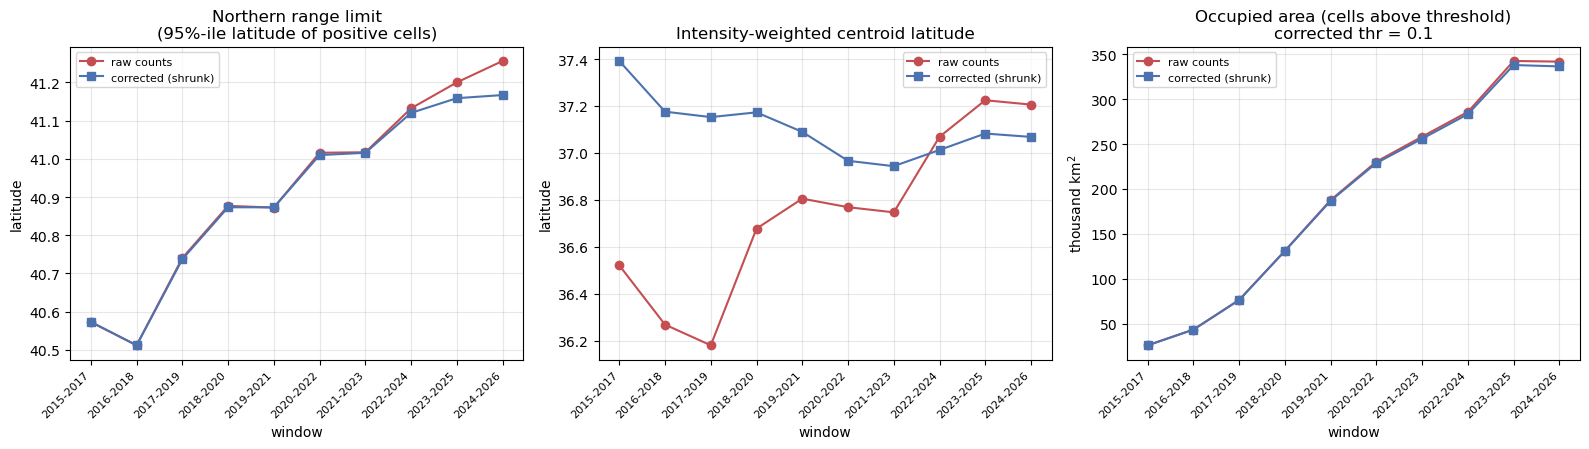

In [6]:
x = frontier["window_end"]
labels = frontier["window"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(x, frontier["raw_northern_limit_lat"], "o-", color="#C44E52",
             label="raw counts")
axes[0].plot(x, frontier["corrected_northern_limit_lat"], "s-", color="#4C72B0",
             label="corrected (shrunk)")
axes[0].set_title(f"Northern range limit\n({config.NORTHERN_LIMIT_PERCENTILE:.0%}-ile latitude of positive cells)")
axes[0].set_ylabel("latitude")

axes[1].plot(x, frontier["raw_centroid_lat"], "o-", color="#C44E52",
             label="raw counts")
axes[1].plot(x, frontier["corrected_centroid_lat"], "s-", color="#4C72B0",
             label="corrected (shrunk)")
axes[1].set_title("Intensity-weighted centroid latitude")
axes[1].set_ylabel("latitude")

axes[2].plot(x, frontier["raw_occupied_area_km2"] / 1e3, "o-", color="#C44E52",
             label="raw counts")
axes[2].plot(x, frontier["corrected_occupied_area_km2"] / 1e3, "s-",
             color="#4C72B0", label="corrected (shrunk)")
axes[2].set_title(f"Occupied area (cells above threshold)\ncorrected thr = {config.OCCUPIED_INTENSITY_THRESHOLD}")
axes[2].set_ylabel("thousand km$^2$")

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("window")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "stage3_frontier_trajectory.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [7]:
# The raw-vs-corrected frontier metrics as a table.
show = frontier[[
    "window", "raw_northern_limit_lat", "corrected_northern_limit_lat",
    "raw_centroid_lat", "corrected_centroid_lat",
    "raw_occupied_cells", "corrected_occupied_cells",
]].copy()
show["d_north"] = show["corrected_northern_limit_lat"] - show["raw_northern_limit_lat"]
show["d_centroid"] = show["corrected_centroid_lat"] - show["raw_centroid_lat"]
show.round(3)

,window,raw_northern_limit_lat,corrected_northern_limit_lat,raw_centroid_lat,corrected_centroid_lat,raw_occupied_cells,corrected_occupied_cells,d_north,d_centroid
0,2015-2017,40.573,40.573,36.522,37.392,103,103,0.000,0.870
1,2016-2018,40.512,40.512,36.270,37.176,172,172,0.000,0.906
2,2017-2019,40.741,40.737,36.182,37.153,303,302,-0.003,0.971
3,2018-2020,40.877,40.873,36.678,37.173,519,518,-0.004,0.495
4,2019-2021,40.872,40.873,36.806,37.090,742,739,0.001,0.284
5,2020-2022,41.016,41.010,36.769,36.967,911,905,-0.006,0.197
6,2021-2023,41.017,41.016,36.747,36.944,1021,1012,-0.001,0.197
7,2022-2024,41.132,41.120,37.069,37.013,1130,1120,-0.012,-0.056
8,2023-2025,41.200,41.159,37.225,37.083,1354,1336,-0.041,-0.142
9,2024-2026,41.256,41.167,37.206,37.068,1351,1330,-0.089,-0.138


## 6. Outputs written + decisions to confirm

Written to `data/processed/`:

| file | grain | key columns |
|---|---|---|
| `effort_corrected_cells.parquet` | h3_cell x window | numerator, denominator, raw_ratio, shrunk_ratio |
| `neon_presence.parquet` | h3_cell x window | lone_star_detected (bool), n_neon_records (intensity only) |
| `frontier_metrics.csv` | window | raw & corrected northern limit / centroid / occupied area |
| `county_detections.parquet` | county_fips x window | n_neon, n_inat, detected (no CDC join yet) |

**Defaults applied (configurable in `config.py`, surfaced for confirmation):**

- window length / step = **3 yr / 1 yr**
- northern-limit definition = **95th-percentile latitude** of positive cells
- corrected "occupied" intensity threshold = **0.10** (lone star >= 10% of iNat
  tick effort); raw "detected" = **>= 1** observation
- county-level uncertainty bound = **50 km**

Stage 3 ends here. Stage 4 (animation) and Stage 5 (CDC validation) are **not**
started.